In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [3]:
df.drop(columns=['product_id'], inplace=True, errors='ignore')
df['order_date'] = pd.to_datetime(df['order_date'])

df.fillna("Unknown", inplace=True)
df.drop_duplicates(inplace=True)

df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[us]
 2   product_category  50000 non-null  str           
 3   price             50000 non-null  float64       
 4   discount_percent  50000 non-null  int64         
 5   quantity_sold     50000 non-null  int64         
 6   customer_region   50000 non-null  str           
 7   payment_method    50000 non-null  str           
 8   rating            50000 non-null  float64       
 9   review_count      50000 non-null  int64         
 10  discounted_price  50000 non-null  float64       
 11  total_revenue     50000 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(4), str(3)
memory usage: 4.6 MB


order_id            0
order_date          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [4]:
print("Mean Rating:", df['rating'].mean())
print("Mean Revenue:", df['total_revenue'].mean())
print("Mean Discount %:", df['discount_percent'].mean())
print("Total Revenue:", df['total_revenue'].sum())

print(df.groupby('product_category')['quantity_sold'].sum())
print(df.groupby('product_category')['rating'].mean())

Mean Rating: 2.9963159999999998
Mean Revenue: 657.3314748
Mean Discount %: 13.3407
Total Revenue: 32866573.740000002
product_category
Beauty            25422
Books             25065
Electronics       24898
Fashion           25089
Home & Kitchen    24743
Sports            24753
Name: quantity_sold, dtype: int64
product_category
Beauty            2.985186
Books             3.020259
Electronics       2.991298
Fashion           2.987782
Home & Kitchen    2.996706
Sports            2.996891
Name: rating, dtype: float64


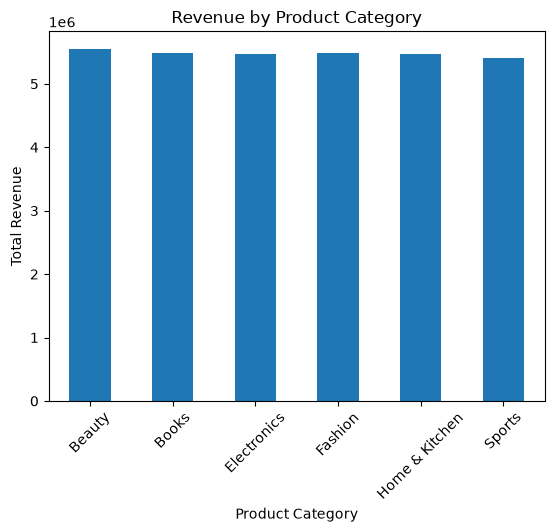

In [5]:
df.groupby('product_category')['total_revenue'].sum().plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

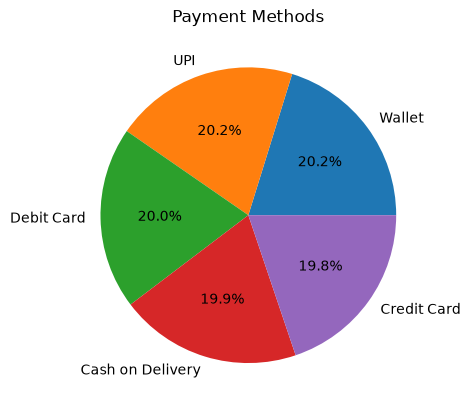

In [6]:
df['payment_method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Methods")
plt.ylabel("")
plt.show()

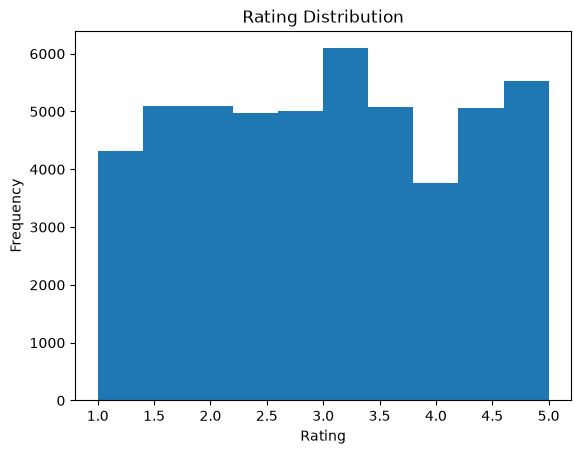

In [7]:
df['rating'].plot(kind='hist', bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.show()

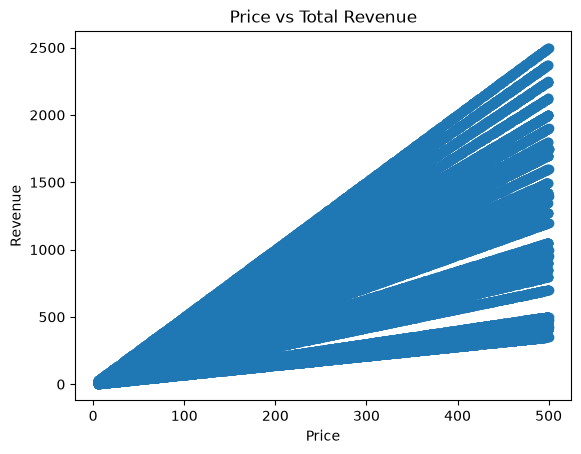

In [8]:
plt.scatter(df['price'], df['total_revenue'])
plt.title("Price vs Total Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.show()

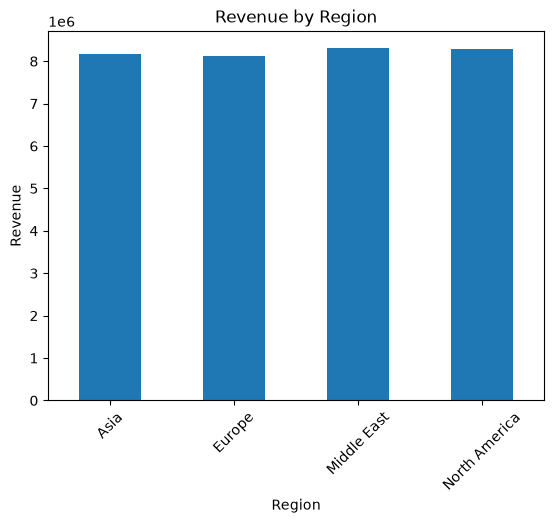

In [9]:
df.groupby('customer_region')['total_revenue'].sum().plot(kind='bar')
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

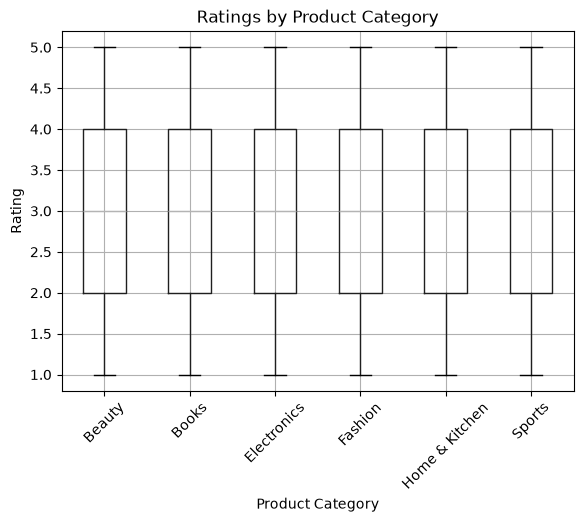

In [10]:
df.boxplot(column='rating', by='product_category', rot=45)
plt.title("Ratings by Product Category")
plt.suptitle("")
plt.xlabel("Product Category")
plt.ylabel("Rating")
plt.show()